In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import pickle
import matplotlib.pyplot as plt

In [ ]:
#전처리 데이터
df = pd.read_csv("/content/iptv_data_preprocessed(50000).csv", encoding='cp949')

In [ ]:
#원본 데이터
df_original=pd.read_csv("/content/SHAP분석용_50000.csv", encoding='cp949')

In [ ]:
# Byte → GB 변환 (1 GB = 1024^3 bytes)
df_original["TotalOctetReceived_GB"] = df_original["TotalOctetReceived"] / (1024 ** 3)
df_original["TotalOctetTransmitted_GB"] = df_original["TotalOctetTransmitted"] / (1024 ** 3)

In [ ]:
# 원본값을 불러올 10개 컬럼
allowed_features = [
    "MonthlyDeviceNumber",
    "TotalOctetReceived",
    "TotalOctetTransmitted",
    "ReAgreementYesNo",
    "WifiSubscriptionYesNo",
    "InternetCount",
    "WingsCount",
    "MaxServiceAfscrbPassoverPeriod",
    "MinAgreementExpirationRemainingMonthCount",
    "InternetProductName"
]

In [ ]:
# 원본 데이터는 10개 컬럼만 필요하므로 10개 컬럼만 필터링합니다
df_original=df_original[allowed_features]

In [ ]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41903 entries, 0 to 41902
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   MonthlyDeviceNumber                        41903 non-null  int64  
 1   TotalOctetReceived                         41903 non-null  float64
 2   TotalOctetTransmitted                      41903 non-null  float64
 3   ReAgreementYesNo                           41903 non-null  object 
 4   WifiSubscriptionYesNo                      41903 non-null  object 
 5   InternetCount                              41903 non-null  int64  
 6   WingsCount                                 41903 non-null  int64  
 7   MaxServiceAfscrbPassoverPeriod             41903 non-null  int64  
 8   MinAgreementExpirationRemainingMonthCount  41903 non-null  int64  
 9   InternetProductName                        41903 non-null  object 
dtypes: float64(2), int64(5

In [ ]:
#기준 정하기 위해 iptv 미가입자 고객 대상으로 수치형 컬럼 통계값 계산
df_original[df_original['iptv_yn']=='N'].describe()

,MonthlyDeviceNumber,TotalOctetReceived,TotalOctetTransmitted,InternetCount,WingsCount,MaxServiceAfscrbPassoverPeriod,MinAgreementExpirationRemainingMonthCount,MaxGeneralConsultationCount,MaxQualityConsultationCount,MaxTermConsultationCount,MaxSaleConsultationCount,MaxFeeConsultationCount,MaxEtcConsultationCount,TotalOctetReceived_GB,TotalOctetTransmitted_GB
count,5141.000000,5.141000e+03,5.141000e+03,5141.000000,5141.000000,5141.000000,5141.000000,5141.000000,5141.000000,5141.000000,5141.000000,5141.000000,5141.000000,5141.000000,5141.000000
mean,12.565843,4.487189e+10,1.548343e+10,1.007586,0.022564,92.718537,7.429488,0.015950,0.012449,0.016534,0.008170,0.008948,0.024509,41.790202,14.420067
std,43.372773,7.845823e+10,4.167649e+10,0.101261,0.148522,84.607468,11.366050,0.125295,0.110889,0.127529,0.090025,0.094177,0.154638,73.069919,38.814256
min,0.000000,0.000000e+00,0.000000e+00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,1.000000,0.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,1.338684e+10,1.456548e+09,1.000000,0.000000,57.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.467465,1.356516
75%,14.000000,6.995781e+10,1.222919e+10,1.000000,0.000000,155.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,65.153287,11.389323
max,1910.000000,1.450000e+12,1.020000e+12,4.000000,1.000000,304.000000,36.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1350.417733,949.949026


In [ ]:
# 1. test set 분리
X_total = df.drop(columns=["iptv_yn"])
y_total = df["iptv_yn"]
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_total, y_total, test_size=0.2, stratify=y_total, random_state=42
)

In [ ]:
# 모델이 iptv_yn을 예측할 데이터는 test set 중에서 미가입자 고객들만 대상이므로 해당 데이터만 X_test_n, y_test_n에 저장합니다
mask_n = (y_test == 0)
X_test_n = X_test[mask_n]
y_test_n = y_test[mask_n]

In [ ]:
# 가장 성능이 높았던 xgboost 모델을 불러옵니다
with open('/content/iptv_xgb(50000).pkl', 'rb') as f:
    data = pickle.load(f)
    model1=data['model']

In [ ]:
# train set으로 모델을 학습시킵니다
model1.fit(X_trainval,y_trainval)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:40:55] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9141412503037608, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None,
              gamma=1.2449394970977086, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.08159743695042095,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=4, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=285, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
# 학습한 모델을 가지고 X_test_n을 예측해봅니다
# 예측 결과
y_pred_n = model1.predict(X_test_n)

# 확률 (Y 클래스 기준)
y_proba_n = model1.predict_proba(X_test_n)[:, 1]

# 결과를 하나의 DataFrame으로 보기 좋게 정리
result_df = X_test_n.copy()
result_df['true_label'] = y_test_n
result_df['pred_label'] = y_pred_n
result_df['proba_Y'] = y_proba_n

In [ ]:
result_df

,ContractPVCName,ResidenceBuildingTypeCode,MonthlyDeviceNumber,TotalOctetReceived,TotalOctetTransmitted,Gender,ReAgreementYesNo,TransferYesNo,WifiSubscriptionYesNo,SalesSmallYesNo,...,MaxQualityConsultationCount,MaxTermConsultationCount,MaxSaleConsultationCount,MaxFeeConsultationCount,MaxEtcConsultationCount,InternetProductName,AgeGroup,true_label,pred_label,proba_Y
33894,6,2,0.327461,0.407923,0.141034,1,0,1,1,0,...,0,0,0,0,0,4,4,0,1,0.810711
24423,5,3,-0.141237,0.155861,0.013442,2,0,1,1,0,...,0,0,0,0,0,4,2,0,0,0.428889
26662,1,2,-0.037082,-0.263321,-0.222941,1,0,1,1,0,...,0,0,0,0,0,4,2,0,1,0.585118
33157,8,3,0.275384,-0.017703,-0.218671,2,0,1,1,0,...,0,0,0,0,0,4,2,0,0,0.499682
13203,1,2,-0.349547,-0.274424,-0.223821,1,0,1,0,0,...,0,0,0,0,0,4,5,0,1,0.722488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33080,7,3,0.275384,0.680855,-0.209967,1,0,1,1,0,...,0,0,0,0,0,2,2,0,1,0.556897
17754,8,2,-0.349547,-0.274424,-0.223821,1,0,1,0,1,...,0,0,0,0,0,4,5,0,0,0.459506
37491,7,2,0.535772,-0.211008,-0.196792,1,0,1,1,0,...,0,0,0,0,0,4,3,0,1,0.712693
29242,8,3,0.067073,-0.115699,-0.210962,1,0,1,1,0,...,0,0,0,0,0,4,2,0,0,0.499442


In [ ]:
# test set에서 미가입자 고객들중 모델은 가입자라고 예측한 고객들, sales talk를 생성해야 하는 고객들만 필터링해 target_customers로 저장합니다
target_customers = result_df[result_df['pred_label']==1]

In [ ]:
#shap분석을 진행해야 하는데 Y값들은 불필요하므로 다음 컬럼들은 drop하여 shap 분석용 X_tc를 만듭니다
X_tc=target_customers.drop(columns=['true_label', 'pred_label', 'proba_Y'])

In [ ]:
len(X_tc)

519

In [ ]:
#shap 분석을 수행하고 각 고객의 원본 값을 가져와야 하므로 df_original에서 X_tc의 각 행과 매칭이 되는 행들만 필터링하여 X_tc_original을 만듭니다
X_tc_original=df_original.loc[X_tc.index]

In [ ]:
!pip install shap
import shap

In [ ]:
# 최신 SHAP explainer로 모델 설명 준비
explainer = shap.Explainer(model1, X_tc)

# SHAP 값 계산 (Explanation 객체 형태로 반환됨)
shap_values = explainer(X_tc)

In [ ]:
# shap 해석에 쓰일 9개 컬럼
shap_features = [
    "MonthlyDeviceNumber",
    "TotalOctetReceived",
    "TotalOctetTransmitted",
    "ReAgreementYesNo",
    "WifiSubscriptionYesNo",
    "InternetCount",
    "WingsCount",
    "MaxServiceAfscrbPassoverPeriod",
    "InternetProductName"
]

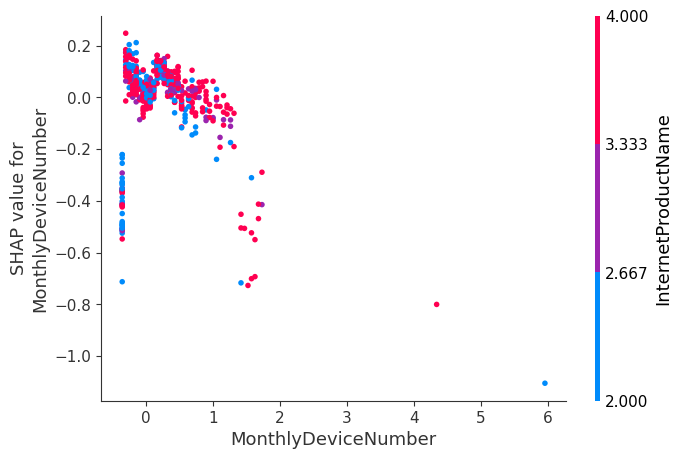

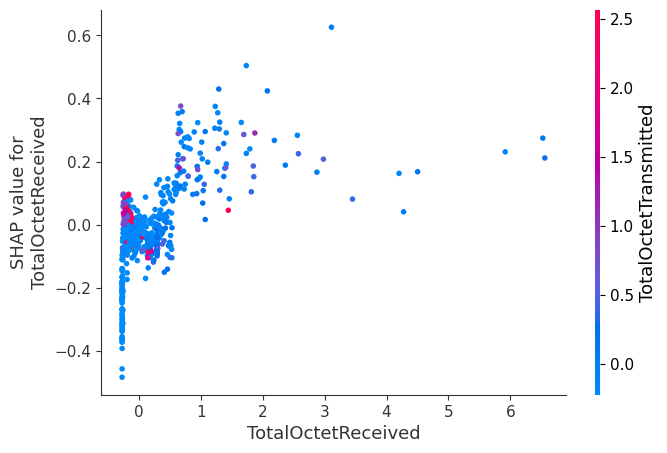

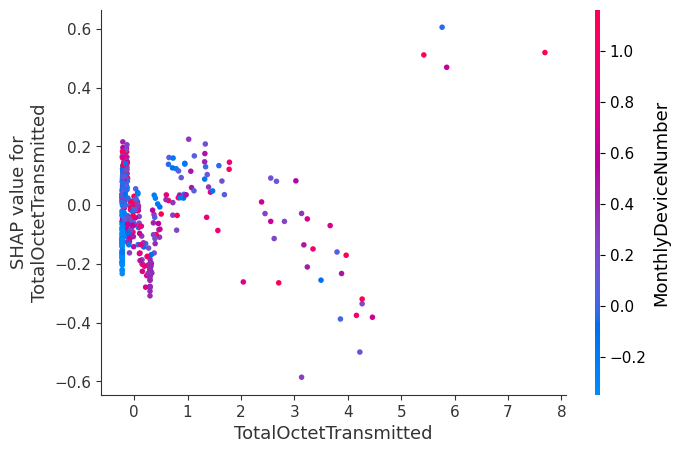

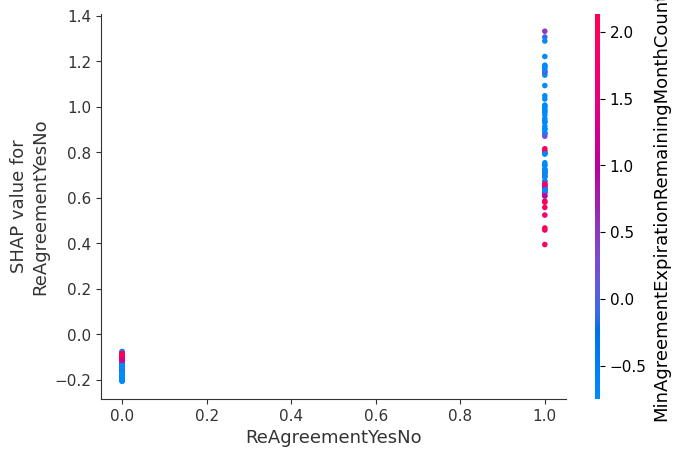

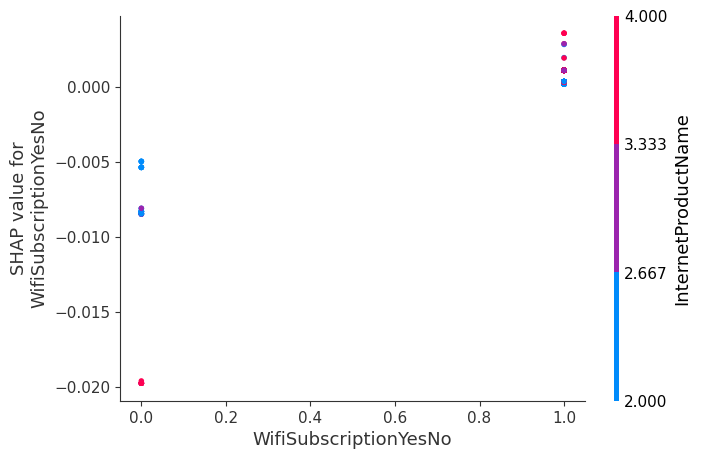

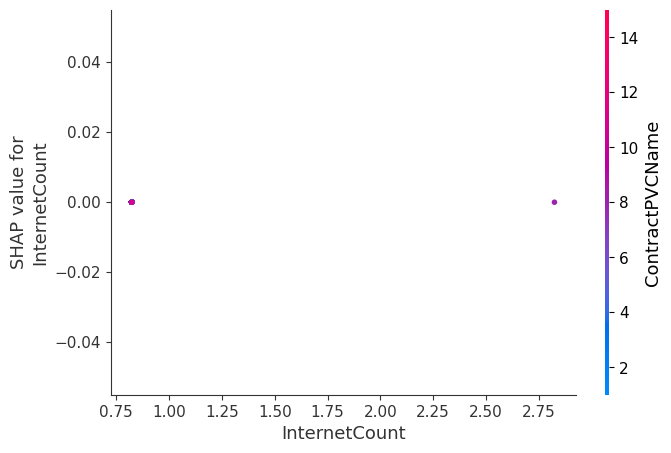

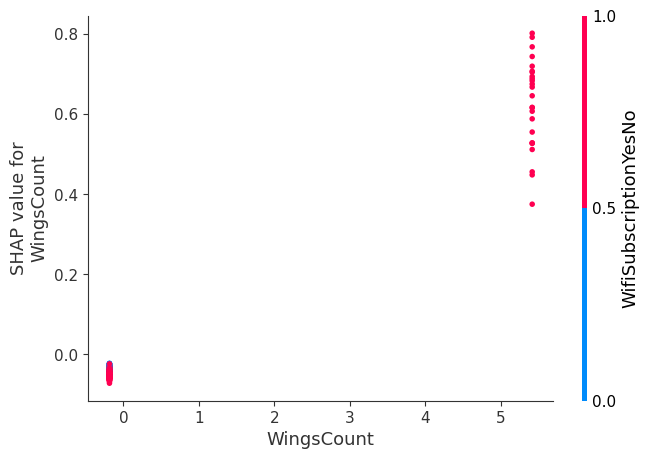

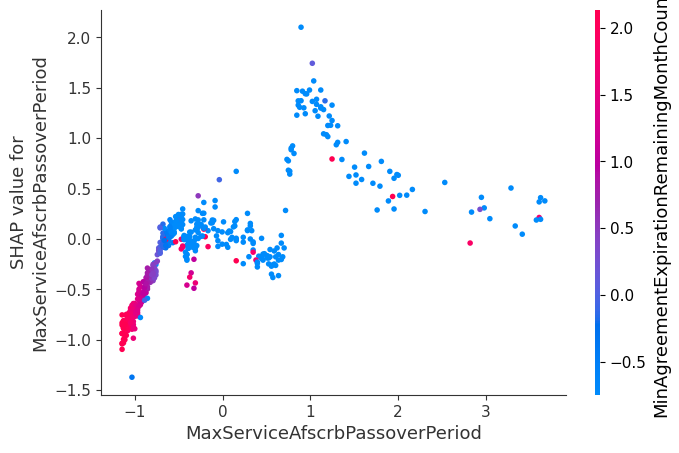

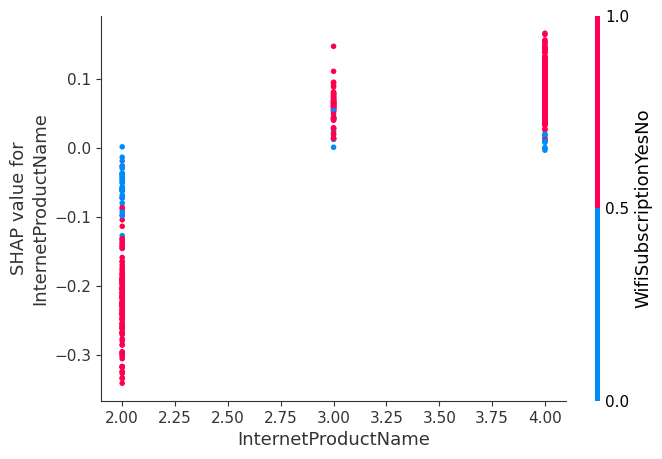

In [ ]:
for feature in shap_features:
  shap.dependence_plot(
    f"{feature}",  # 분석할 feature
    shap_values.values,                          # SHAP 값
    features=X_tc,                            # X: 모델 입력값
    feature_names=X_tc.columns)              # 컬럼 이름

In [ ]:
len(shap_values)

519

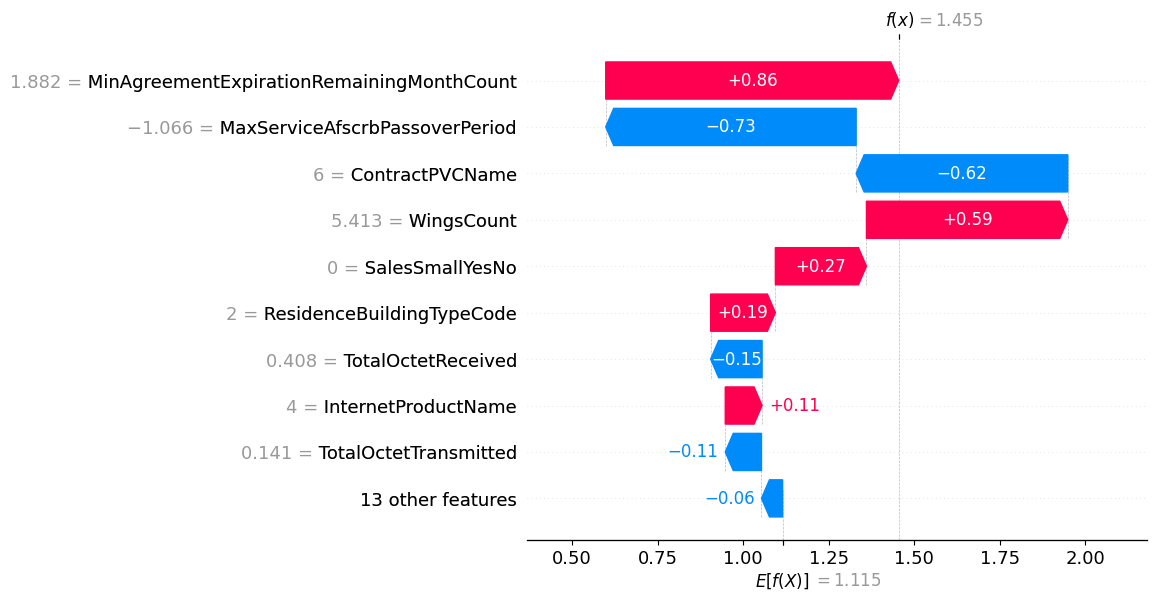

In [ ]:
# 첫 번째 사용자에 대한 영향력 waterfall plot
shap.plots.waterfall(shap_values[0], max_display=10)

In [ ]:
top_features_list = []

for i in range(len(shap_values)):
    shap_df = pd.DataFrame({
        'feature': shap_values[i].feature_names,
        'shap': shap_values[i].values
    })

    # 원본 값을 가져오기 (이게 핵심!)
    original_values = X_tc_original.iloc[i]  # 시리즈 형태

    # 여기에 value 컬럼 추가
    shap_df['value'] = shap_df['feature'].map(original_values)

    # allowed_features 중 shap 값이 양수인 상위 3개 추출
    top9 = (
        shap_df[
            (shap_df['shap'] > 0) & (shap_df['feature'].isin(shap_features))
        ]
        .sort_values(by='shap', ascending=False)
    )

    top9['customer_index'] = i+1
    top_features_list.append(top9)

top_features_df = pd.concat(top_features_list, ignore_index=True)


In [ ]:
df_shap=top_features_df

In [ ]:
df_mean_list.to_csv("/content/customer_feature_list.csv", index=False, encoding='utf-8-sig')

In [ ]:
df_shap=pd.read_csv("/content/shap_분석결과1.csv")

In [ ]:
df_shap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2019 entries, 0 to 2018
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   feature         2019 non-null   object 
 1   shap            2019 non-null   float64
 2   value           2019 non-null   object 
 3   customer_index  2019 non-null   int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 63.2+ KB


In [ ]:
df_shap

,feature,shap,value,customer_index
0,WingsCount,0.588307,1,1
1,InternetProductName,0.107572,기가라이트,1
2,MonthlyDeviceNumber,0.082020,13,1
3,WifiSubscriptionYesNo,0.001099,Y,1
4,InternetProductName,0.087180,기가라이트,2
...,...,...,...,...
2014,MonthlyDeviceNumber,0.120121,12,518
2015,WifiSubscriptionYesNo,0.000352,Y,518
2016,InternetProductName,0.131729,기가라이트,519
2017,TotalOctetTransmitted,0.088790,1263440399.0,519


In [ ]:
numeric_features = [
    "WingsCount",
    "MaxServiceAfscrbPassoverPeriod",
    "MonthlyDeviceNumber",
    "TotalOctetReceived",
    "TotalOctetTransmitted",
    "InternetCount"
]

for feature in numeric_features:
  mask=df_shap["feature"] == feature
  df_shap.loc[mask,'value']=pd.to_numeric(df_shap.loc[mask,"value"],errors='coerce')

df_shap['type']=df_shap['value'].apply(type)

df_shap[df_shap['feature'].isin(numeric_features)].head(10)

,feature,shap,value,customer_index,type
0,WingsCount,0.588307,1,1,<class 'int'>
2,MonthlyDeviceNumber,0.082020,13,1,<class 'int'>
5,MonthlyDeviceNumber,0.011360,6,2,<class 'int'>
6,TotalOctetTransmitted,0.009235,41144854.0,2,<class 'float'>
8,TotalOctetTransmitted,0.113389,3190100286.0,4,<class 'float'>
9,TotalOctetReceived,0.103082,108000000000.0,4,<class 'float'>
12,MaxServiceAfscrbPassoverPeriod,0.133255,36,5,<class 'int'>
13,MonthlyDeviceNumber,0.130520,10,5,<class 'int'>
16,MonthlyDeviceNumber,0.060194,14,6,<class 'int'>
20,TotalOctetTransmitted,0.102300,2575070004.0,8,<class 'float'>


In [ ]:
# 필터: feature가 TotalOctetReceived인 행만 추출
mask = df_shap["feature"] == "TotalOctetReceived"

# feature 이름 변경
df_shap.loc[mask, "feature"] = "TotalOctetReceived_GB"

mask = df_shap["feature"] == "TotalOctetReceived_GB"
# value를 숫자로 변환 후 byte → GB (1GB = 1e+9), 반올림하여 정수로
#df_shap.loc[mask, "value"] = pd.to_numeric(df_shap.loc[mask, "value"], errors="coerce")
df_shap.loc[mask, "value"] = (df_shap.loc[mask, "value"]/1e9).round(3)

# 변경 후 확인
df_shap[mask].head()

,feature,shap,value,customer_index,type
9,TotalOctetReceived_GB,0.103082,108.0,4,<class 'float'>
24,TotalOctetReceived_GB,0.153538,132.0,9,<class 'float'>
30,TotalOctetReceived_GB,0.013038,84.184822,10,<class 'float'>
34,TotalOctetReceived_GB,0.101651,77.458705,11,<class 'float'>
37,TotalOctetReceived_GB,0.174790,151.0,12,<class 'float'>


In [ ]:
# 필터: feature가 TotalOctetTransmitted인 행만 추출
mask = df_shap["feature"] == "TotalOctetTransmitted"

# feature 이름 변경
df_shap.loc[mask, "feature"] = "TotalOctetTransmitted_GB"

mask = df_shap["feature"] == "TotalOctetTransmitted_GB"
# value를 숫자로 변환 후 byte → GB (1GB = 1e+9), 반올림하여 정수로
#df_shap.loc[mask, "value"] = pd.to_numeric(df_shap.loc[mask, "value"], errors="coerce")
df_shap.loc[mask, "value"] = (df_shap.loc[mask, "value"]/1e9).round(3)

# 변경 후 확인
df_shap[mask].head()

,feature,shap,value,customer_index,type
6,TotalOctetTransmitted_GB,0.009235,0.041145,2,<class 'float'>
8,TotalOctetTransmitted_GB,0.113389,3.1901,4,<class 'float'>
20,TotalOctetTransmitted_GB,0.102300,2.57507,8,<class 'float'>
31,TotalOctetTransmitted_GB,0.008465,1.820758,10,<class 'float'>
42,TotalOctetTransmitted_GB,0.122442,1.726179,13,<class 'float'>


In [ ]:
df_shap.drop(["type"],axis=1,inplace=True)

In [ ]:
# MonthlyDeviceNumber가 6 미만인 행 제거
mask_mdn = (df_shap["feature"] == "MonthlyDeviceNumber") & (pd.to_numeric(df_shap["value"], errors="coerce")< 6)

# 해당 행 제거
df_shap = df_shap.drop(index=df_shap[mask_mdn].index).reset_index(drop=True)

# 확인
df_shap[df_shap["feature"] == "MonthlyDeviceNumber"].head()

,feature,shap,value,customer_index
2,MonthlyDeviceNumber,0.082020,13,1
5,MonthlyDeviceNumber,0.011360,6,2
13,MonthlyDeviceNumber,0.130520,10,5
16,MonthlyDeviceNumber,0.060194,14,6
25,MonthlyDeviceNumber,0.095716,10,9


In [ ]:
# TotalOctetReceived_GB가 12.467 미만인 행 제거
mask_received = (df_shap["feature"] == "TotalOctetReceived_GB") & (pd.to_numeric(df_shap["value"], errors="coerce") < 12.467)
df_shap = df_shap.drop(index=df_shap[mask_received].index)

# TotalOctetTransmitted_GB가 1.356 미만인 행 제거
mask_transmitted = (df_shap["feature"] == "TotalOctetTransmitted_GB") & (pd.to_numeric(df_shap["value"], errors="coerce") < 1.356)
df_shap = df_shap.drop(index=df_shap[mask_transmitted].index)

# 인덱스 재정렬
df_shap.reset_index(drop=True, inplace=True)

# 확인
df_shap[(df_shap["feature"] == "TotalOctetReceived_GB") | (df_shap["feature"] == "TotalOctetTransmitted_GB")].head()

,feature,shap,value,customer_index
7,TotalOctetTransmitted_GB,0.113389,3.1901,4
8,TotalOctetReceived_GB,0.103082,108.0,4
19,TotalOctetTransmitted_GB,0.102300,2.57507,8
22,TotalOctetReceived_GB,0.153538,132.0,9
28,TotalOctetReceived_GB,0.013038,84.184822,10


In [ ]:
# InternetCount가 1인 행 제거
mask_internet = (df_shap["feature"] == "InternetCount") & (pd.to_numeric(df_shap["value"], errors="coerce") == 1)
df_shap = df_shap.drop(index=df_shap[mask_internet].index)

# WingsCount가 0인 행 제거
mask_wings = (df_shap["feature"] == "WingsCount") & (pd.to_numeric(df_shap["value"], errors="coerce") == 0)
df_shap = df_shap.drop(index=df_shap[mask_wings].index)

# 인덱스 재정렬
df_shap.reset_index(drop=True, inplace=True)

# 확인
df_shap[(df_shap["feature"] == "InternetCount") | (df_shap["feature"] == "WingsCount")].head()

,feature,shap,value,customer_index
0,WingsCount,0.588307,1,1
38,WingsCount,0.688579,1,13
250,WingsCount,0.555312,1,79
334,WingsCount,0.675093,1,101
405,WingsCount,0.455959,1,120


In [ ]:
# MaxServiceAfscrbPassoverPeriod < 57 인 행 제거
mask_service_period = (df_shap["feature"] == "MaxServiceAfscrbPassoverPeriod") & (pd.to_numeric(df_shap["value"], errors="coerce") < 57)
df_shap = df_shap.drop(index=df_shap[mask_service_period].index)

# ReAgreementYesNo == 'N' 인 행 제거
mask_reagreement = (df_shap["feature"] == "ReAgreementYesNo") & (df_shap["value"] == "N")
df_shap = df_shap.drop(index=df_shap[mask_reagreement].index)

# WifiSubscriptionYesNo == 'N' 인 행 제거
mask_wifi = (df_shap["feature"] == "WifiSubscriptionYesNo") & (df_shap["value"] == "N")
df_shap = df_shap.drop(index=df_shap[mask_wifi].index)

# 인덱스 재정렬
df_shap.reset_index(drop=True, inplace=True)

# 확인
df_shap[
    (df_shap["feature"] == "MaxServiceAfscrbPassoverPeriod") |
    (df_shap["feature"] == "ReAgreementYesNo") |
    (df_shap["feature"] == "WifiSubscriptionYesNo")
].head()


,feature,shap,value,customer_index
3,WifiSubscriptionYesNo,0.001099,Y,1
6,WifiSubscriptionYesNo,0.001099,Y,2
10,WifiSubscriptionYesNo,0.000308,Y,4
13,WifiSubscriptionYesNo,0.001099,Y,5
16,WifiSubscriptionYesNo,0.001099,Y,6


In [ ]:
internet_product_values = df_shap[df_shap["feature"] == "InternetProductName"]["value"].unique().tolist()
internet_product_values

['기가라이트', '기가', '광랜']

In [ ]:
# InternetProductName이 '광랜'인 행 제거
mask_gwanglan = (df_shap["feature"] == "InternetProductName") & (df_shap["value"] == "광랜")
df_shap = df_shap.drop(index=df_shap[mask_gwanglan].index).reset_index(drop=True)

# 확인
df_shap[df_shap["feature"] == "InternetProductName"].head()

,feature,shap,value,customer_index
1,InternetProductName,0.107572,기가라이트,1
4,InternetProductName,0.087180,기가라이트,2
9,InternetProductName,0.098389,기가라이트,4
12,InternetProductName,0.096221,기가라이트,5
15,InternetProductName,0.042389,기가,6


In [ ]:
# 우선 MonthlyDeviceNumber, TotalOctetReceived_GB, TotalOctetTransmitted_GB 중에서
# 같은 고객이면 shap 값이 가장 높은 feature 하나만 남기기
def select_highest_feature(group):
    # 위 세 feature가 모두 있다면 shap 값이 가장 높은 것 하나만 남기고
    important_features = ["MonthlyDeviceNumber", "TotalOctetReceived_GB", "TotalOctetTransmitted_GB"]
    important_rows = group[group["feature"].isin(important_features)]
    if not important_rows.empty:
        top_row = important_rows.sort_values(by="shap", ascending=False).head(1)
        group = pd.concat([group[~group["feature"].isin(important_features)], top_row])
    return group

# 고객별로 적용
df_shap_selected = df_shap.groupby("customer_index", group_keys=False).apply(select_highest_feature)

# 이후 고객당 최대 3개만 남기기 (shap 값 기준 내림차순)
df_shap_top3 = (
    df_shap_selected
    .sort_values(by=["customer_index", "shap"], ascending=[True, False])
    .groupby("customer_index")
    .head(3)
    .reset_index(drop=True)
)

<ipython-input-47-de98831d9987>:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_shap_selected = df_shap.groupby("customer_index", group_keys=False).apply(select_highest_feature)


In [ ]:
df_shap.to_csv("/content/SHAP_분석결과.csv", index=False, encoding='utf-8-sig')

In [ ]:
X_tc_original.to_csv("고객 원본.csv", index=False, encoding='utf-8-sig')

In [ ]:
X_tc_original = X_tc_original.reset_index().rename(columns={"index": "customer_index"})

In [ ]:
X_tc_original

,customer_index,MonthlyDeviceNumber,TotalOctetReceived,TotalOctetTransmitted,ReAgreementYesNo,WifiSubscriptionYesNo,InternetCount,WingsCount,MaxServiceAfscrbPassoverPeriod,MinAgreementExpirationRemainingMonthCount,InternetProductName
0,1,13,8.428632e+10,1.705462e+10,N,Y,1,1,6,31,기가라이트
1,2,6,1.371480e+09,4.114485e+07,N,Y,1,0,4,33,기가라이트
2,3,0,0.000000e+00,0.000000e+00,N,N,1,0,20,17,기가라이트
3,4,39,1.080000e+11,3.190100e+09,N,Y,1,0,104,0,기가라이트
4,5,10,4.463785e+10,1.763013e+09,N,Y,1,0,36,1,기가라이트
...,...,...,...,...,...,...,...,...,...,...,...
514,515,16,3.871770e+09,6.068916e+10,Y,Y,1,0,112,0,광랜
515,516,9,9.878294e+10,8.260692e+08,N,Y,1,0,82,0,기가라이트
516,517,9,2.574185e+09,5.164906e+10,N,Y,1,0,69,0,광랜
517,518,12,1.180000e+11,6.476233e+08,N,Y,1,0,11,26,광랜


In [ ]:
# 우선 customer_index별로 몇 개 feature가 있는지 세기
count_per_customer = df_shap_top3["customer_index"].value_counts()

# feature가 2개 이하인 customer_index 추출
customers_with_less_than_3 = count_per_customer[count_per_customer <= 2].index

In [ ]:
# 다시 시도: feature가 2개 이하인 고객 중 MinAgreementExpirationRemainingMonthCount이 1, 2, 3인 경우 추가
rows_to_add = []

for idx in customers_with_less_than_3:
    # customer_index로 매칭
    row = X_tc_original[X_tc_original["customer_index"] == idx]
    if not row.empty:
        min_agreement = row["MinAgreementExpirationRemainingMonthCount"].values[0]
        if min_agreement in [1, 2, 3]:
            new_row = {
                "customer_index": idx,
                "feature": "MinAgreementExpirationRemainingMonthCount",
                "value": min_agreement,
                "shap": 0
            }
            rows_to_add.append(new_row)

# 추가할 행들을 데이터프레임으로 만들기
df_additional = pd.DataFrame(rows_to_add)

# 기존 df_shap_top3와 추가된 df_additional 합치기
df_shap_final = pd.concat([df_shap_top3, df_additional], ignore_index=True)

# 다시 customer_index와 shap 기준으로 정렬
df_shap_final = (
    df_shap_final
    .sort_values(by=["customer_index", "shap"], ascending=[True, False])
    .reset_index(drop=True)
)

In [ ]:
df_shap_final["feature"].unique()

array(['WingsCount', 'InternetProductName', 'MonthlyDeviceNumber',
       'WifiSubscriptionYesNo', 'TotalOctetTransmitted_GB',
       'ReAgreementYesNo', 'MaxServiceAfscrbPassoverPeriod',
       'TotalOctetReceived_GB',
       'MinAgreementExpirationRemainingMonthCount'], dtype=object)

In [ ]:
df_shap_final

,feature,shap,value,customer_index,mean
0,WingsCount,0.588307,1,1,윙즈(와이파이 확장기) 사용 고객
1,InternetProductName,0.107572,기가라이트,1,기가인터넷 이용 고객
2,MonthlyDeviceNumber,0.082020,13,1,와이파이 접속 기기 대수가 많은 고객
3,InternetProductName,0.087180,기가라이트,2,기가인터넷 이용 고객
4,MonthlyDeviceNumber,0.011360,6,2,와이파이 접속 기기 대수가 많은 고객
...,...,...,...,...,...
1288,WifiSubscriptionYesNo,0.000352,Y,517,SK브로드밴드 와이파이 공유기 사용 고객
1289,TotalOctetReceived_GB,0.261536,118.0,518,데이터 수신량이 많은 고객
1290,WifiSubscriptionYesNo,0.000352,Y,518,SK브로드밴드 와이파이 공유기 사용 고객
1291,InternetProductName,0.131729,기가라이트,519,기가인터넷 이용 고객


In [ ]:
# feature에 따른 mean 설명 매핑
feature_to_mean = {
    "MonthlyDeviceNumber": "와이파이 접속 기기 대수가 많은 고객",
    "TotalOctetReceived_GB": "데이터 수신량이 많은 고객",
    "TotalOctetTransmitted_GB": "데이터 송신량이 많은 고객",
    "MaxServiceAfscrbPassoverPeriod": "장기고객",
    "WingsCount": "윙즈(와이파이 확장기) 사용 고객",
    "WifiSubscriptionYesNo": "SK브로드밴드 와이파이 공유기 사용 고객",
    "ReAgreementYesNo": "재약정 이력이 있는 고객",
    "InternetProductName": "기가인터넷 이용 고객",
    "MinAgreementExpirationRemainingMonthCount": "약정기간이 얼마 남지 않은 고객"
}

# mean 컬럼 추가
df_shap_final["mean"] = df_shap_final["feature"].map(feature_to_mean)

In [ ]:
# 고객별로 mean을 쉼표(", ")로 이어붙이기
df_mean_list = (
    df_shap_final
    .groupby("customer_index")["mean"]
    .apply(lambda x: ", ".join(x))
    .reset_index()
    .rename(columns={"mean": "feature_list"})
)

<ipython-input-8-ce7faafeaedd>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_df.sort_values(by="value",inplace=True)


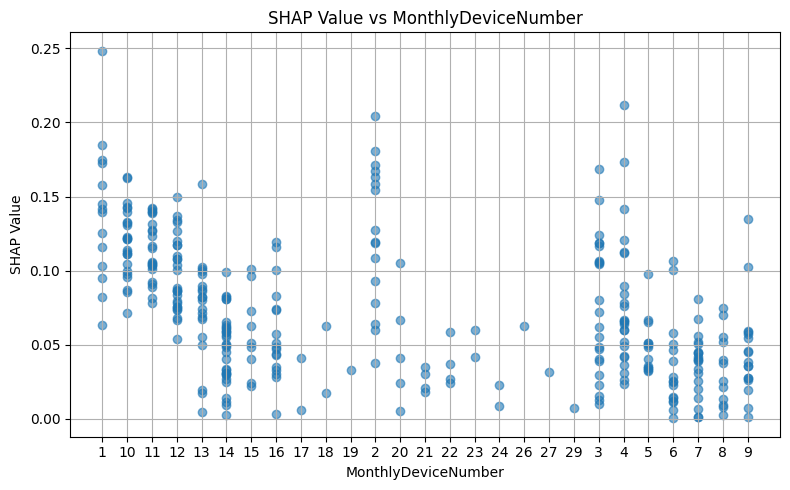

In [ ]:
# 필터: MonthlyDeviceNumber만
monthly_df = top_features_df[top_features_df["feature"] == "MonthlyDeviceNumber"]
monthly_df.sort_values(by="value",inplace=True)
# 산점도 그래프 그리기
plt.figure(figsize=(8, 5))
plt.scatter(monthly_df["value"], monthly_df["shap"], alpha=0.6)
plt.title("SHAP Value vs MonthlyDeviceNumber")
plt.xlabel("MonthlyDeviceNumber")
plt.ylabel("SHAP Value")
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-10-bf069df17ad2>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_df.sort_values(by="value",inplace=True)


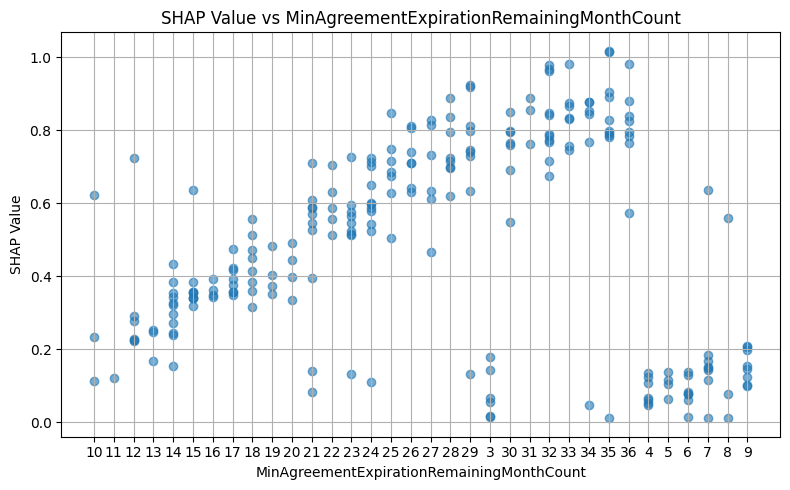

In [ ]:
# 필터: MinAgreementExpirationRemainingMonthCount만
monthly_df = top_features_df[top_features_df["feature"] == "MinAgreementExpirationRemainingMonthCount"]
monthly_df.sort_values(by="value",inplace=True)
# 산점도 그래프 그리기
plt.figure(figsize=(8, 5))
plt.scatter(monthly_df["value"], monthly_df["shap"], alpha=0.6)
plt.title("SHAP Value vs MinAgreementExpirationRemainingMonthCount")
plt.xlabel("MinAgreementExpirationRemainingMonthCount")
plt.ylabel("SHAP Value")
plt.grid(True)
plt.tight_layout()
plt.show()

<ipython-input-13-51f8b9015620>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_df.sort_values(by="value",inplace=True)


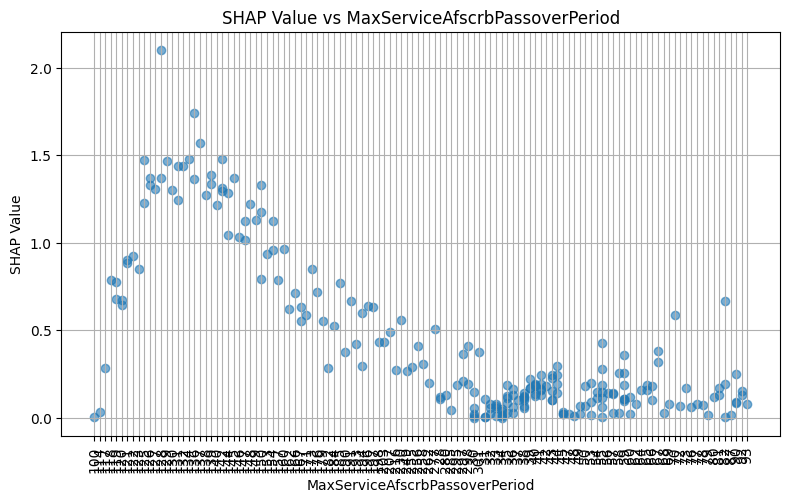

In [ ]:
# 필터: MaxServiceAfscrbPassoverPeriod만
monthly_df = top_features_df[top_features_df["feature"] == "MaxServiceAfscrbPassoverPeriod"]
monthly_df.sort_values(by="value",inplace=True)
# 산점도 그래프 그리기
plt.figure(figsize=(8, 5))
plt.scatter(monthly_df["value"], monthly_df["shap"], alpha=0.6)
plt.title("SHAP Value vs MaxServiceAfscrbPassoverPeriod")
plt.xlabel("MaxServiceAfscrbPassoverPeriod")
plt.ylabel("SHAP Value")
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [ ]:
value_counts_min=X_tc_original['MonthlyDeviceNumber'].value_counts().sort_index()

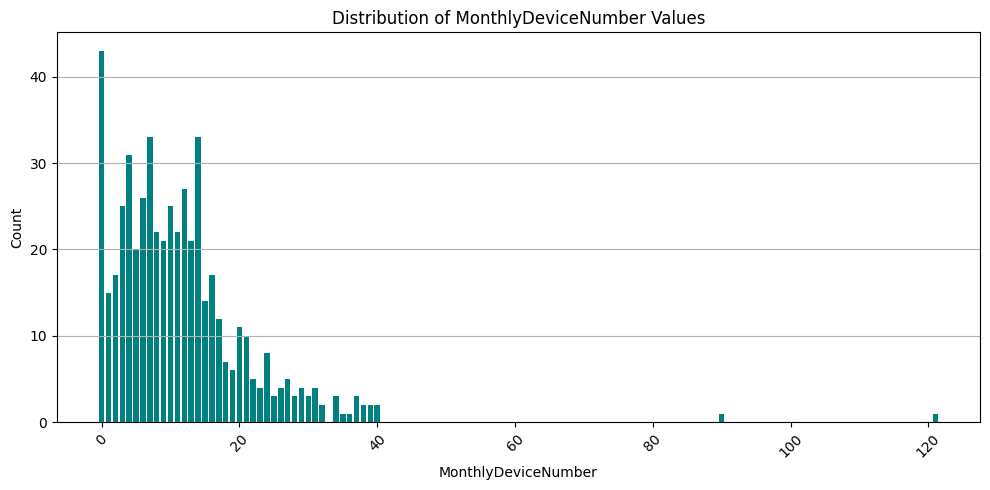

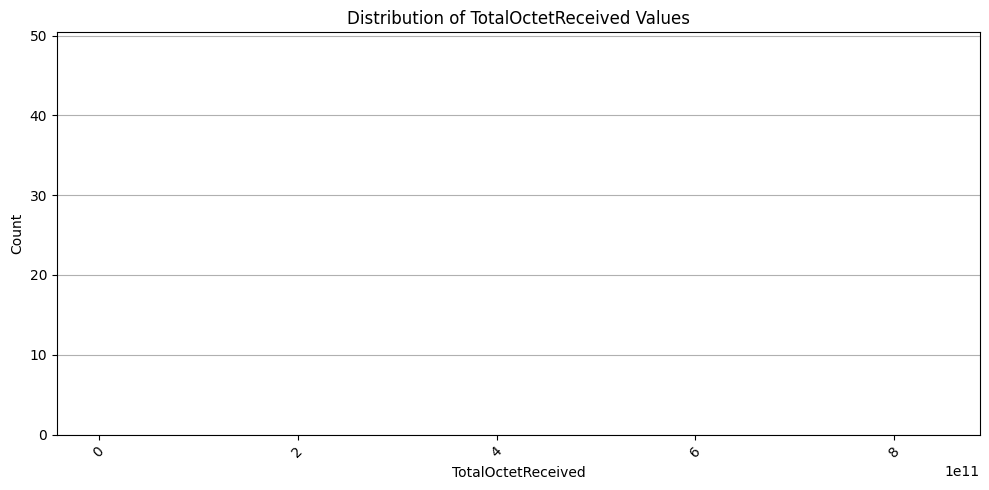

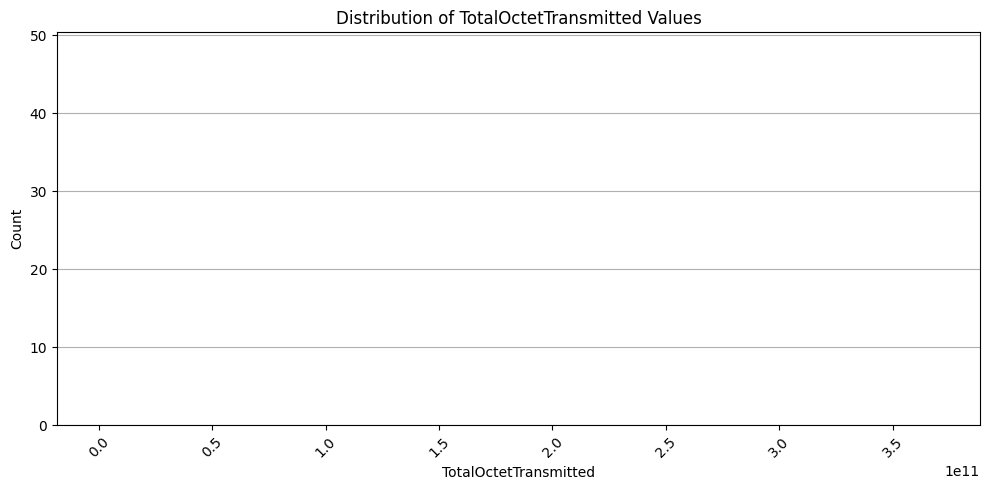

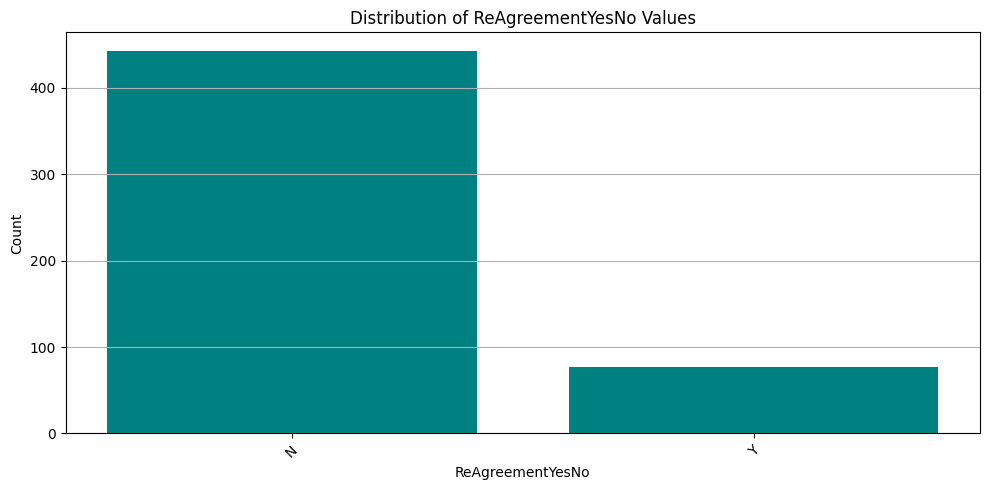

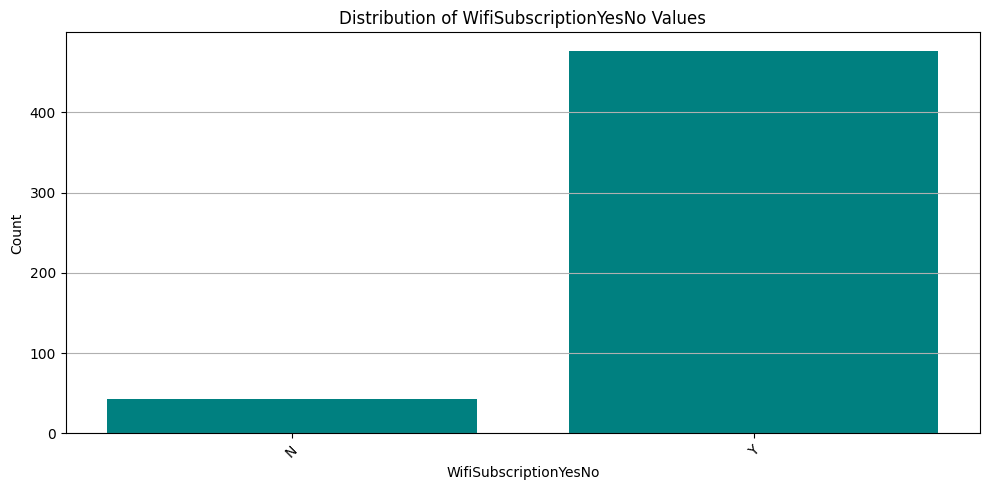

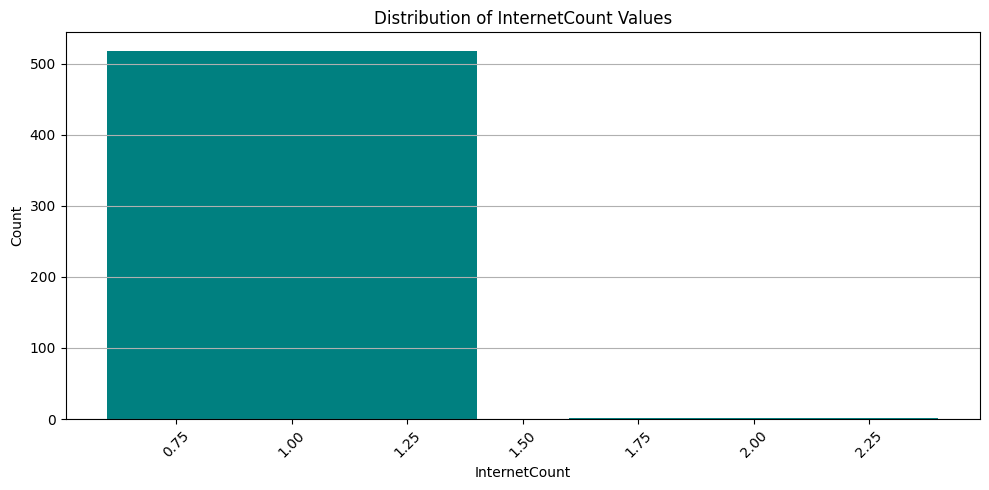

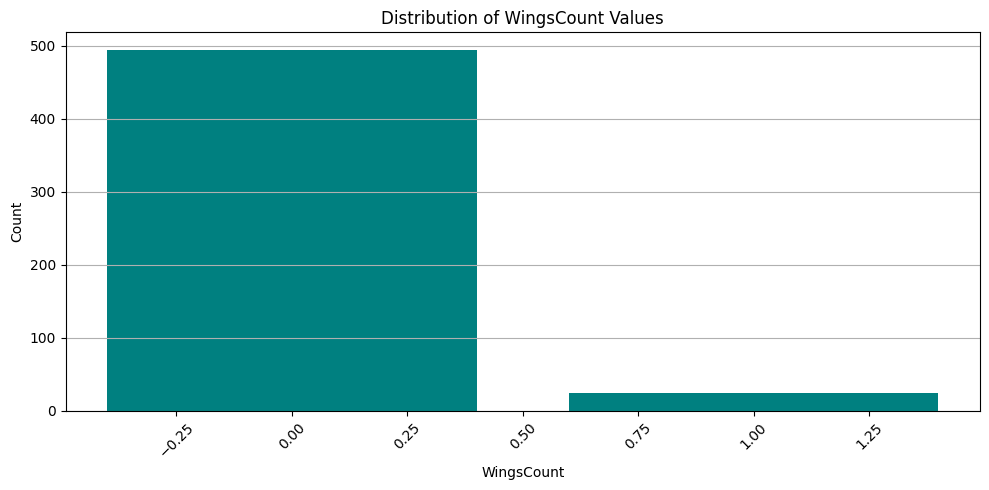

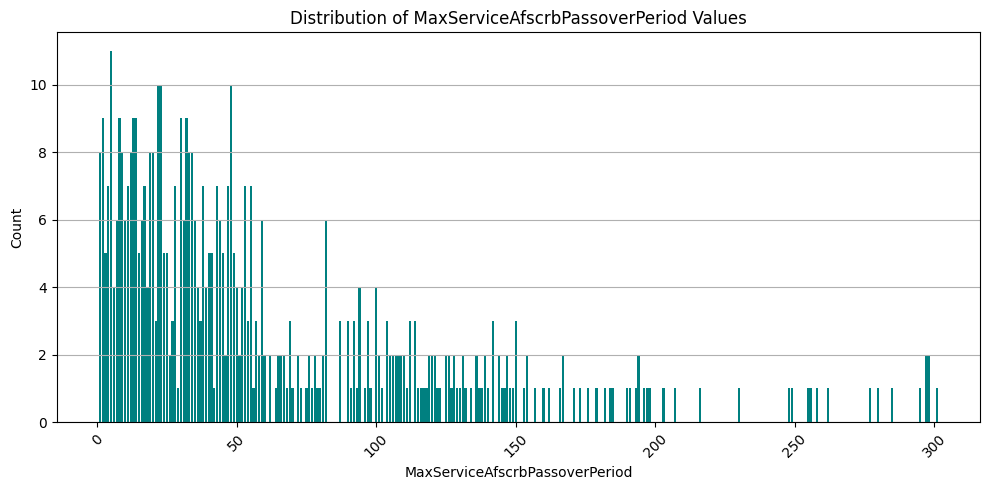

<ipython-input-34-e9d6453dac87>:10: UserWarning: Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-34-e9d6453dac87>:10: UserWarning: Glyph 47004 (\N{HANGUL SYLLABLE RAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-34-e9d6453dac87>:10: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-34-e9d6453dac87>:10: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-34-e9d6453dac87>:10: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-34-e9d6453dac87>:10: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-34-e9d6453dac87>:10: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/loc

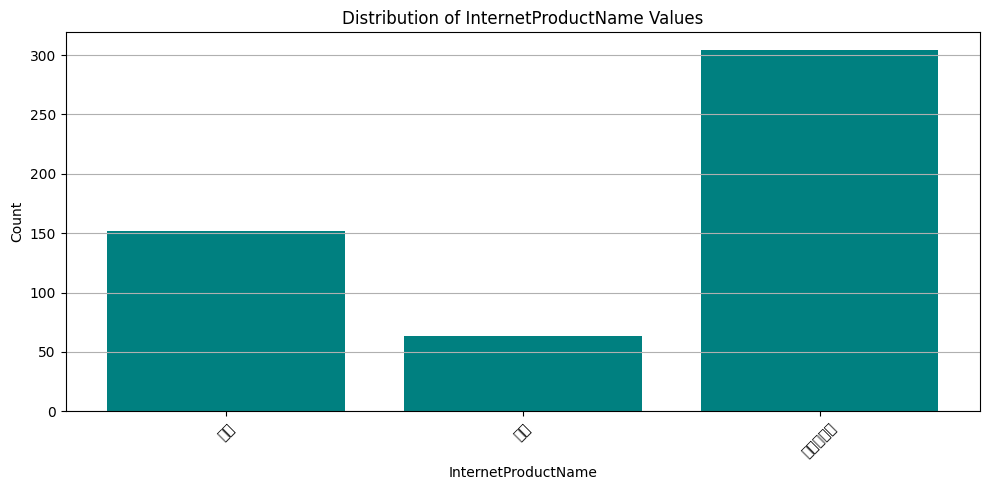

In [ ]:
for feature in allowed_features:
  value_counts=X_tc_original[feature].value_counts().sort_index()
  plt.figure(figsize=(10, 5))
  plt.bar(value_counts.index, value_counts.values, color='teal')
  plt.title(f"Distribution of {feature} Values")
  plt.xlabel(f"{feature}")
  plt.ylabel("Count")
  plt.xticks(rotation=45)
  plt.grid(axis='y')
  plt.tight_layout()
  plt.show()

In [ ]:
value_counts_min=X_tc_original['MinAgreementExpirationRemainingMonthCount'].value_counts().sort_index()

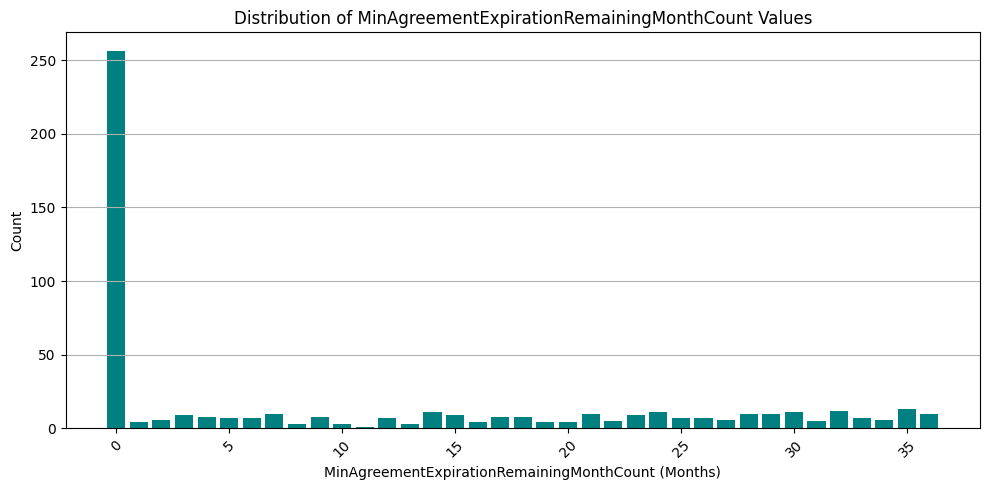

In [ ]:
# Plotting
plt.figure(figsize=(10, 5))
plt.bar(value_counts_min.index.astype(int), value_counts_min.values, color='teal')
plt.title("Distribution of MinAgreementExpirationRemainingMonthCount Values")
plt.xlabel("MinAgreementExpirationRemainingMonthCount (Months)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

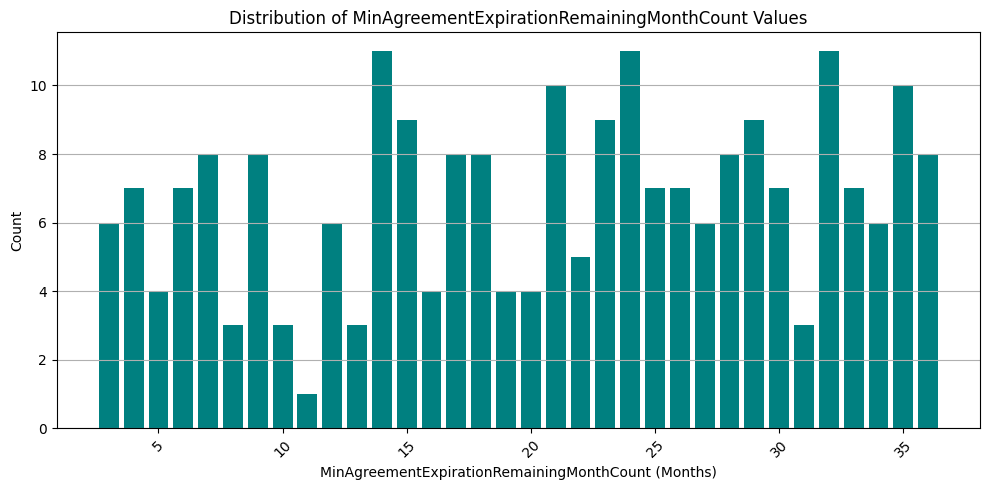

In [ ]:
# Filter rows for feature = "MinAgreementExpirationRemainingMonthCount"
min_agreement_df = top_features_df[top_features_df["feature"] == "MinAgreementExpirationRemainingMonthCount"].copy()

# Ensure value is numeric
min_agreement_df["value"] = pd.to_numeric(min_agreement_df["value"], errors='coerce')

# Count of each value
value_counts = min_agreement_df["value"].value_counts().sort_index()

# Plotting
plt.figure(figsize=(10, 5))
plt.bar(value_counts.index.astype(int), value_counts.values, color='teal')
plt.title("Distribution of MinAgreementExpirationRemainingMonthCount Values")
plt.xlabel("MinAgreementExpirationRemainingMonthCount (Months)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
